# Классификация. Деревья решений

Бабошин Никита Андреевич (6401-010203D)

## Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

Ссылка на источник: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

In [1]:
import kagglehub
import pandas as pd
import os

path1 = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
file_path = os.path.join(path1, 'E Commerce Dataset.xlsx')
df = pd.read_excel(file_path, sheet_name='E Comm', usecols='A:T')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Датасет и подготовка данных

### Привести описание датасета

Датасет "Ecommerce Customer Churn Analysis and Prediction" содержит данные, собранные ведущей онлайн-компанией электронной коммерции для анализа и прогнозирования оттока клиентов (churn). В нём представлены различные признаки клиентов, включая уникальный идентификатор, флаг оттока, срок сотрудничества с компанией и т.п. Цель датасета — выявить клиентов, которые, вероятно, прекратят пользоваться услугами, чтобы компания могла предложить им специальные промо-акции и удержать.

Целевой признак: `Churn`

In [2]:
dictData = pd.read_excel(file_path, sheet_name='Data Dict', usecols='C:D', skiprows=1)
dictData

,Variable,Discerption
0,CustomerID,Unique customer ID
1,Churn,Churn Flag
2,Tenure,Tenure of customer in organization
3,PreferredLoginDevice,Preferred login device of customer
4,CityTier,City tier
5,WarehouseToHome,Distance in between warehouse to home of customer
6,PreferredPaymentMode,Preferred payment method of customer
7,Gender,Gender of customer
8,HourSpendOnApp,Number of hours spend on mobile application or...
9,NumberOfDeviceRegistered,Total number of deceives is registered on part...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

### Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные"

#### Удаление признака CustomerID (не несет никакой информации)

In [4]:
df = df.drop(['CustomerID'], axis=1)

#### Катигориальные и числовые признаки

In [5]:
cat_columns = df.select_dtypes(include="str").columns.tolist()

num_columns = []
for col in df.columns:
    if col not in cat_columns:
        num_columns.append(col)

print("Numerical columns: ", num_columns)
print("Categorical columns: ", cat_columns)

Numerical columns:  ['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical columns:  ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


Совместим похожие по смыслу значения в категориальных признаках

In [6]:
# Заменяем 'Mobile Phone' на 'Phone' в PreferredLoginDevice
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Mobile Phone', 'Phone')

# Заменяем 'Credit Card' на 'CC' в PreferredPaymentMode
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('Credit Card', 'CC')

# Заменяем 'Mobile Phone' на 'Mobile' в PreferedOrderCat
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile Phone', 'Mobile')

Заполнение пропусков средним значением

In [7]:
df[num_columns].isnull().sum()

Churn                            0
Tenure                         264
CityTier                         0
WarehouseToHome                251
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
SatisfactionScore                0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [8]:
for col in num_columns:
    df[col] = df[col].fillna(df[col].mean())

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5630 non-null   float64
 2   PreferredLoginDevice         5630 non-null   str    
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   str    
 6   Gender                       5630 non-null   str    
 7   HourSpendOnApp               5630 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   str    
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   str    
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain                     

### Закодировать категориальные признаки при необходимости

One-Hot Encoding для категориальных признаков

In [9]:
df = pd.get_dummies(df, columns=cat_columns, drop_first=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  5630 non-null   int64  
 1   Tenure                                 5630 non-null   float64
 2   CityTier                               5630 non-null   int64  
 3   WarehouseToHome                        5630 non-null   float64
 4   HourSpendOnApp                         5630 non-null   float64
 5   NumberOfDeviceRegistered               5630 non-null   int64  
 6   SatisfactionScore                      5630 non-null   int64  
 7   NumberOfAddress                        5630 non-null   int64  
 8   Complain                               5630 non-null   int64  
 9   OrderAmountHikeFromlastYear            5630 non-null   float64
 10  CouponUsed                             5630 non-null   float64
 11  OrderCount     

### Разбить выборку на обучающую и тестовую.

> Далее используем обучающую выборку, в том числе для метрик.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Нормализовать данные

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### При наличии дисбаланса классов снизить дисбаланс классов

In [12]:
y_train.value_counts(normalize=True)

Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

In [13]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

In [14]:
y_train.value_counts(normalize=True)

Churn
1    0.504628
0    0.495372
Name: proportion, dtype: float64

## Дерево решений

### С использованием `GridSearchCV` осуществить подбор гиперпараметра `DecisionTreeClassifier`

(как минимум `max_depth`, `max_features`, другие параметры &ndash; по желанию.)

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

# Сетка параметров
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': range(2, 27, 2),
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': range(2, 27, 2), 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

### Вывести значения гиперпараметра и метрик для наилучшей модели `DecisionTreeClassifier` ($accuracy$, $precision$, $recall$, $\textit{f-measure}$)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

best_model_dt = grid_search.best_estimator_
y_pred = best_model_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
prec_dt = precision_score(y_test, y_pred)
rec_dt = recall_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall: {rec_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 20, 'max_features': 18, 'min_samples_leaf': 1}
Лучший score на валидации: 0.9314302379535329

Accuracy: 0.9396
Precision: 0.7877
Recall: 0.8789
F1-score: 0.8308

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       936
           1       0.79      0.88      0.83       190

    accuracy                           0.94      1126
   macro avg       0.88      0.92      0.90      1126
weighted avg       0.94      0.94      0.94      1126



### Для полученного наилучшего дерева вывести `feature_importances`, отсортировать их по убыванию

In [17]:
importance_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': best_model_dt.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
0,Tenure,0.291003
11,DaySinceLastOrder,0.090443
6,NumberOfAddress,0.079541
7,Complain,0.078245
5,SatisfactionScore,0.058976
12,CashbackAmount,0.058354
2,WarehouseToHome,0.044171
21,PreferedOrderCat_Laptop & Accessory,0.042009
8,OrderAmountHikeFromlastYear,0.035328
4,NumberOfDeviceRegistered,0.032482


### Осуществить фильтрацию признаков

Фильтрацию признаков проведем путем отсечения по порогу = 0.03

In [18]:
filtered_features = importance_df[importance_df['importance'] > 0.03]
filtered_features

,feature,importance
0,Tenure,0.291003
11,DaySinceLastOrder,0.090443
6,NumberOfAddress,0.079541
7,Complain,0.078245
5,SatisfactionScore,0.058976
12,CashbackAmount,0.058354
2,WarehouseToHome,0.044171
21,PreferedOrderCat_Laptop & Accessory,0.042009
8,OrderAmountHikeFromlastYear,0.035328
4,NumberOfDeviceRegistered,0.032482


In [19]:
selected_indices_dt = filtered_features.index.tolist()
X_train_f = X_train[:, selected_indices_dt]
X_test_f = X_test[:, selected_indices_dt]

### Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками

In [20]:
dt = DecisionTreeClassifier(random_state=42)

# Сетка параметров
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': range(2, 11),
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_f, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': range(2, 11), 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

### Вывести полученные гиперпараметры лучшей модели

In [21]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_f)

acc_dt_f = accuracy_score(y_test, y_pred)
prec_dt_f = precision_score(y_test, y_pred)
rec_dt_f = recall_score(y_test, y_pred)
f1_dt_f = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_dt_f:.4f}")
print(f"Precision: {prec_dt_f:.4f}")
print(f"Recall: {rec_dt_f:.4f}")
print(f"F1-score: {f1_dt_f:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': None, 'max_features': 4, 'min_samples_leaf': 1}
Лучший score на валидации: 0.9303483549666248

Accuracy: 0.9556
Precision: 0.8608
Recall: 0.8789
F1-score: 0.8698

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       936
           1       0.86      0.88      0.87       190

    accuracy                           0.96      1126
   macro avg       0.92      0.93      0.92      1126
weighted avg       0.96      0.96      0.96      1126



### Сравнить метрики до и после фильтрации признаков лучших моделей

In [22]:
pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Base': [acc_dt, prec_dt, rec_dt, f1_dt],
    'Filtered': [acc_dt_f, prec_dt_f, rec_dt_f, f1_dt_f],
    'Delta': [
        acc_dt_f - acc_dt,
        prec_dt_f - prec_dt,
        rec_dt_f - rec_dt,
        f1_dt_f - f1_dt
    ]
}).round(4)

,Metric,Base,Filtered,Delta
0,Accuracy,0.9396,0.9556,0.0160
1,Precision,0.7877,0.8608,0.0731
2,Recall,0.8789,0.8789,0.0000
3,F1-score,0.8308,0.8698,0.0389


Фильтрация признаков по порогу важности позволила улучшить обобщающую способность модели дерева решений: точность (Accuracy) выросла на 1.6%, что свидетельствует о снижении количества ошибочных прогнозов в целом. Наиболее значительный прирост наблюдается по метрике Precision (точность положительных предсказаний) — увеличение на 7.31% при сохранении полноты (Recall) на прежнем уровне. Удаление малоинформативных признаков, вероятно, снизило уровень шума в данных и уменьшило переобучение.

## Случайный лес

### Построить случайный лес (`RandomForestClassifier`), c использованием `GridSearchCV` осуществить подбор гиперпараметра

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': range(2, 27, 2)
}

grid_search1 = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': range(2, 27, 2), 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

### Вывести полученные гиперпараметры лучшей модели случайного леса

In [24]:
grid_search1.best_params_, grid_search1.best_score_

({'max_depth': None, 'max_features': 2, 'n_estimators': 100},
 np.float64(0.9778566584144016))

### Осуществить фильтрацию признаков

In [25]:
importance_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': grid_search1.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
0,Tenure,0.156959
12,CashbackAmount,0.074239
11,DaySinceLastOrder,0.067143
2,WarehouseToHome,0.057844
6,NumberOfAddress,0.057678
4,NumberOfDeviceRegistered,0.055847
8,OrderAmountHikeFromlastYear,0.055548
5,SatisfactionScore,0.055505
7,Complain,0.053974
9,CouponUsed,0.046721


In [26]:
filtered_features = importance_df[importance_df['importance'] > 0.03]
filtered_features

,feature,importance
0,Tenure,0.156959
12,CashbackAmount,0.074239
11,DaySinceLastOrder,0.067143
2,WarehouseToHome,0.057844
6,NumberOfAddress,0.057678
4,NumberOfDeviceRegistered,0.055847
8,OrderAmountHikeFromlastYear,0.055548
5,SatisfactionScore,0.055505
7,Complain,0.053974
9,CouponUsed,0.046721


In [27]:
selected_indices_rf = filtered_features.index.tolist()
X_train_f = X_train[:, selected_indices_rf]
X_test_f = X_test[:, selected_indices_rf]

### Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками

In [28]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'max_features': range(2, 11)
}

grid_search2 = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search2.fit(X_train_f, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': range(2, 11), 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

### Вывести полученные гиперпараметры лучшей модели случайного леса

In [29]:
grid_search2.best_params_, grid_search2.best_score_

({'max_depth': None, 'max_features': 3, 'n_estimators': 100},
 np.float64(0.9604703944576212))

### Сравнить метрики до и после фильтрации признаков лучших моделей

In [30]:
y_pred = grid_search1.best_estimator_.predict(X_test)
y_pred_f = grid_search2.best_estimator_.predict(X_test_f)

acc_rf = accuracy_score(y_test, y_pred)
prec_rf = precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

acc_rf_f = accuracy_score(y_test, y_pred_f)
prec_rf_f = precision_score(y_test, y_pred_f)
rec_rf_f = recall_score(y_test, y_pred_f)
f1_rf_f = f1_score(y_test, y_pred_f)

pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Base': [acc_rf, prec_rf, rec_rf, f1_rf],
    'Filtered': [acc_rf_f, prec_rf_f, rec_rf_f, f1_rf_f],
    'Delta': [
        acc_rf_f - acc_rf,
        prec_rf_f - prec_rf,
        rec_rf_f - rec_rf,
        f1_rf_f - f1_rf
    ]
}).round(4)

,Metric,Base,Filtered,Delta
0,Accuracy,0.9698,0.9636,-0.0062
1,Precision,0.9699,0.8984,-0.0715
2,Recall,0.8474,0.8842,0.0368
3,F1-score,0.9045,0.8912,-0.0132


В отличие от дерева решений, фильтрация признаков для случайного леса привела к незначительному ухудшению качества модели. Несмотря на рост полноты (Recall) на 3.68% (модель стала находить больше истинных объектов целевого класса), точность (Precision) резко снизилась на 7.15%. Для бизнеса важнее как раз полнота (Recall), чтобы не упускать клиентов, склонных к оттоку, поэтому фильтрацию признаков можно считать в какой-то степени успешной.

Данное наблюдение позволяет предположить, что ансамблевый метод (случайный лес) эффективнее использует широкий набор признаков, и отбрасывание части из них даже с низкой важностью нарушает внутренние компенсаторные механизмы модели.

## Метод ближайших соседей

### С использованием `GridSearchCV` осуществить подбор гиперпараметра `KNeighborsClassifier` (`n_neighbors`)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

### Вывести значения гиперпараметра и метрик для наилучшей модели

In [32]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred)
prec_knn = precision_score(y_test, y_pred)
rec_knn = recall_score(y_test, y_pred)
f1_knn = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall: {rec_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'n_neighbors': 1}
Лучший score на валидации: 0.985453844459132

Accuracy: 0.9813
Precision: 0.9082
Recall: 0.9895
F1-score: 0.9471

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       936
           1       0.91      0.99      0.95       190

    accuracy                           0.98      1126
   macro avg       0.95      0.98      0.97      1126
weighted avg       0.98      0.98      0.98      1126



### Осуществить фильтрацию признаков

In [33]:
from sklearn.feature_selection import SequentialFeatureSelector

knn_s = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn_s, direction='backward', n_features_to_select='auto', cv=5)

sfs.fit(X_train, y_train)
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 13


Сохраним индексы отфильтрованных признаков:

In [34]:
selected_indices_knn = sfs.get_support(indices=True)

### Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками

In [35]:
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_sel, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

### Вывести полученные гиперпараметры лучшей модели KNN

In [36]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_sel)

acc_knn_f = accuracy_score(y_test, y_pred)
prec_knn_f = precision_score(y_test, y_pred)
rec_knn_f = recall_score(y_test, y_pred)
f1_knn_f = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_knn_f:.4f}")
print(f"Precision: {prec_knn_f:.4f}")
print(f"Recall: {rec_knn_f:.4f}")
print(f"F1-score: {f1_knn_f:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'n_neighbors': 1}
Лучший score на валидации: 0.9890243113475103

Accuracy: 0.9964
Precision: 0.9794
Recall: 1.0000
F1-score: 0.9896

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       936
           1       0.98      1.00      0.99       190

    accuracy                           1.00      1126
   macro avg       0.99      1.00      0.99      1126
weighted avg       1.00      1.00      1.00      1126



### Сравнить метрики до и после фильтрации признаков

In [37]:
pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Base': [acc_knn, prec_knn, rec_knn, f1_knn],
    'Filtered': [acc_knn_f, prec_knn_f, rec_knn_f, f1_knn_f],
    'Delta': [
        acc_knn_f - acc_knn,
        prec_knn_f - prec_knn,
        rec_knn_f - rec_knn,
        f1_knn_f - f1_knn
    ]
}).round(4)

,Metric,Base,Filtered,Delta
0,Accuracy,0.9813,0.9964,0.0151
1,Precision,0.9082,0.9794,0.0712
2,Recall,0.9895,1.0000,0.0105
3,F1-score,0.9471,0.9896,0.0425


Применение последовательного отбора признаков позволило значительно улучшить качество модели KNN. Наблюдается прирост по всем ключевым метрикам: точность модели (Accuracy) увеличилась на 1.51% и достигла практически эталонных 99.64%. Наиболее впечатляющий скачок произошел по метрике Precision, которая выросла на 7.12% — теперь модель ошибается крайне редко. Полнота (Recall) достигла максимума (1.0), что означает обнаружение всех без исключения уходящих клиентов. Удаление лишних признаков с помощью SFS, вероятно, позволило устранить «проклятие размерности», критичное для методов, основанных на расстояниях, и оставить только наиболее информативные признаки для построения компактных и чистых кластеров в пространстве.

 ## Построение моделей для набора отфильтрованных признаков
 
 Если наблюдается улучшение метрик после фильтрации признаков хотя бы для одной из моделей, то для набора отфильтрованных признаков (пересечение множеств отфильтрованных признаков каждой модели или объединение множеств &ndash; не особо важно, главное описать, каким образом получен новый subset данных) заново построить наилучшие модели `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier`, сравнить модели в пункте 7 на одинаковом полученном наборе отфильтрованных признаков. Иначе &ndash; пропустить этот пункт.

Индексы признаков

In [38]:
print(f"DT({len(selected_indices_dt)}):  {selected_indices_dt}")
print(f"RF({len(selected_indices_rf)}):  {selected_indices_rf}")
print(f"KNN({len(selected_indices_knn)}): {selected_indices_knn}")

DT(10):  [0, 11, 6, 7, 5, 12, 2, 21, 8, 4]
RF(13):  [0, 12, 11, 2, 6, 4, 8, 5, 7, 9, 10, 3, 22]
KNN(13): [ 0  1  2  5  6  7  8 16 17 19 21 22 25]


Отберем признаки путем голосования (признак встречается >= 2 моделях)

In [39]:
from collections import Counter

all_indices = selected_indices_dt + selected_indices_rf + list(selected_indices_knn)
votes = Counter(all_indices)
voting_indices = sorted([idx for idx, count in votes.items() if count >= 2])

print(f"{len(voting_indices)} признаков:")
print(voting_indices)

11 признаков:
[0, 2, 4, 5, 6, 7, 8, 11, 12, 21, 22]


Формирование subset-а данных

In [40]:
X_train_vote = X_train[:, voting_indices]
X_test_vote = X_test[:, voting_indices]

Построение наилучших моделей

In [41]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'max_features': range(2, 11),
        'min_samples_leaf': [1, 2, 5, 10, 20]
    },
    cv=5,
    scoring='f1',
    n_jobs=-1
)
dt_grid.fit(X_train_vote, y_train)
print(f"Лучшие параметры: {dt_grid.best_params_}")
print(f"Лучший score: {dt_grid.best_score_}")

Лучшие параметры: {'max_depth': None, 'max_features': 10, 'min_samples_leaf': 1}
Лучший score: 0.9335464173032346


In [42]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': [50, 100],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'max_features': range(2, 11)
    },
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_grid.fit(X_train_vote, y_train)
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший score: {rf_grid.best_score_}")

Лучшие параметры: {'max_depth': None, 'max_features': 2, 'n_estimators': 100}
Лучший score: 0.9671611159071386


In [43]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5,
    scoring='f1',
    n_jobs=-1
)
knn_grid.fit(X_train_vote, y_train)
print(f"Лучшие параметры: {knn_grid.best_params_}")
print(f"Лучший score: {knn_grid.best_score_}")

Лучшие параметры: {'n_neighbors': 1}
Лучший score: 0.9617301670235404


Список лучших моделей

In [44]:
best_models = {
    'KNN': knn_grid.best_estimator_,
    'DT': dt_grid.best_estimator_,
    'RF': rf_grid.best_estimator_
}

## Оценка качества построенных моделей

### Визуализировать любое полученное дерево решений

> Для вывода названий признаков в граф необходимо задать значение аргумента `feature_names` в `sklearn.tree.export_graphviz`, для вывода названий классов &ndash; `class_names` (перед кодированием целевого признака можно сохранить названия в отдельный массив).

Воспользуюсь `sklearn.tree.plot_tree`, а не `sklearn.tree.export_graphviz` (проще) и ограничу глубину дерева до 3 уровня для читаемости

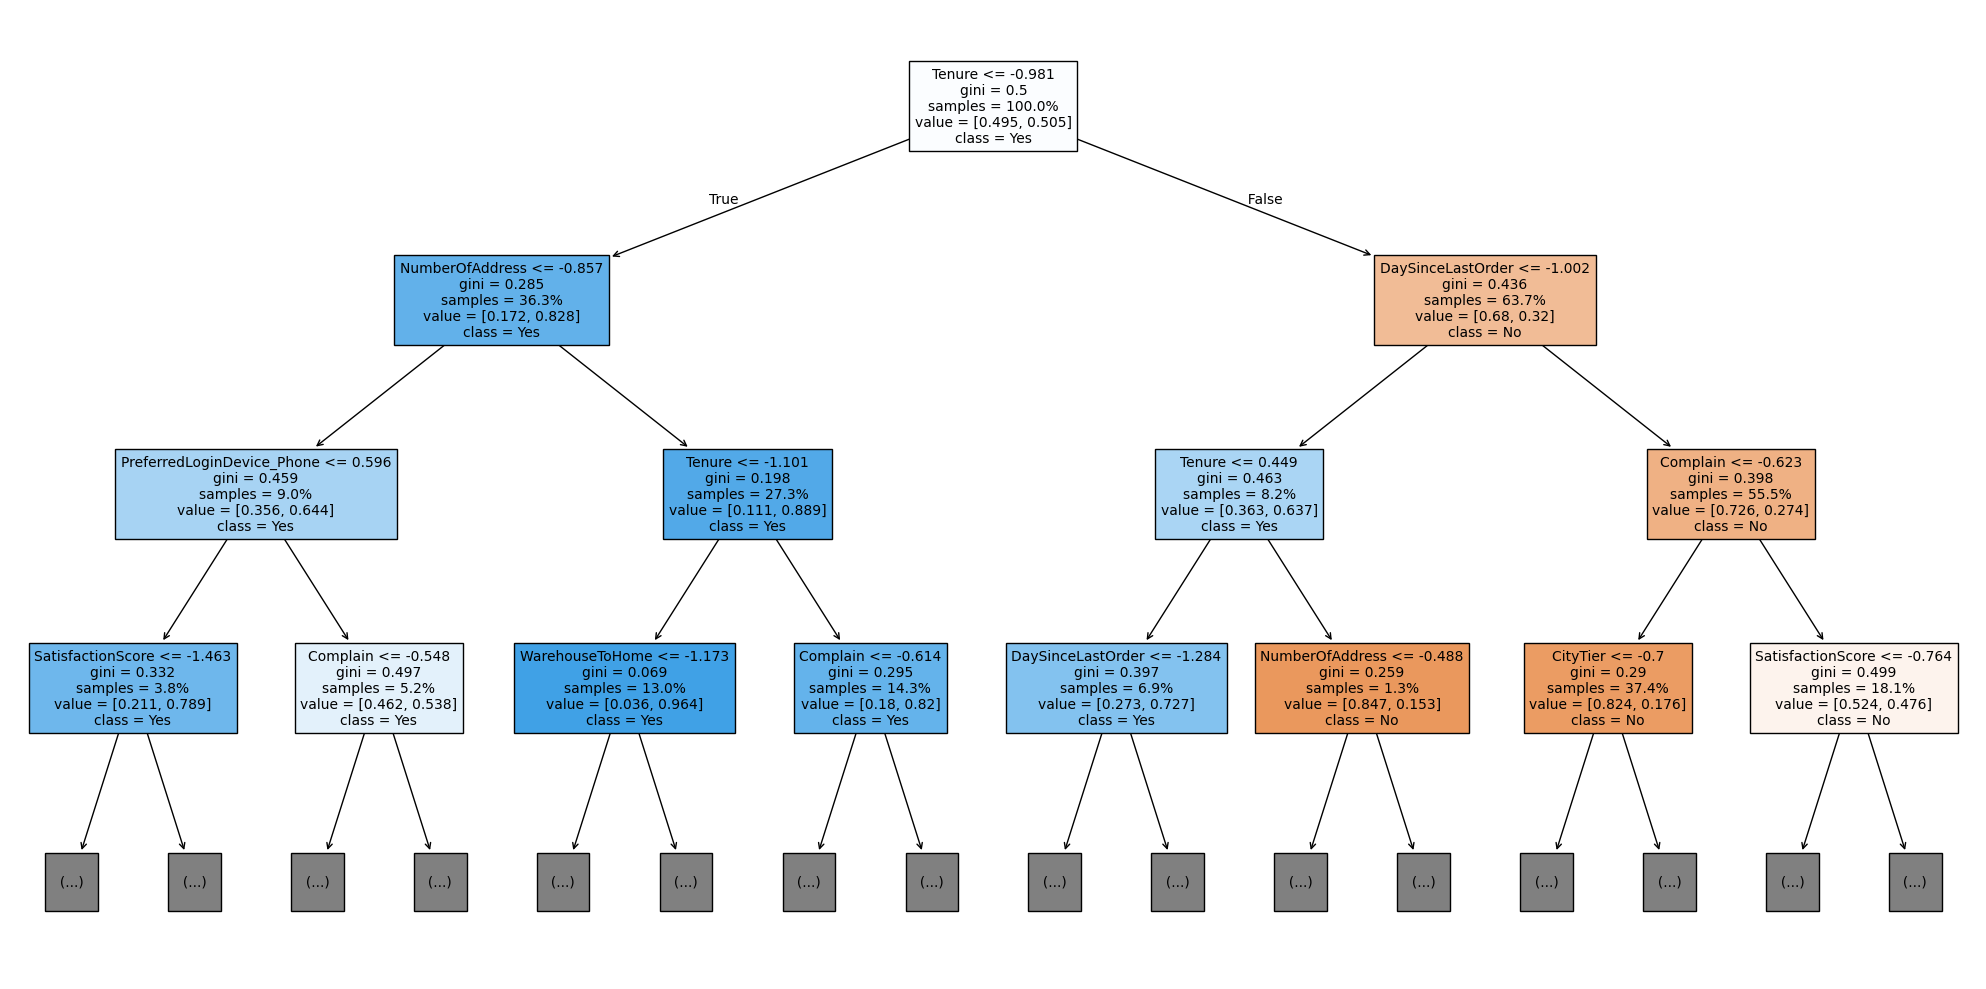

In [45]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

class_names = ['No', 'Yes']

plt.figure(figsize=(20, 10))
plot_tree(
    best_model_dt,
    feature_names=X.columns.tolist(),
    class_names=class_names,
    filled=True,
    fontsize=10,
    max_depth=3,
    proportion=True
)

plt.tight_layout()
plt.show()

### Сравнить лучшие модели `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier` на **тестовой выборке**. Привести значения метрик $accuracy$, $precision$, $recall$, $\textit{f-measure}$

Лучшие модели построенные на наборе отфильтрованных признаков

In [46]:
results_list = []

for name, model in best_models.items():
    model.fit(X_train_vote, y_train)
    y_pred = model.predict(X_test_vote)
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_score': f1_score(y_test, y_pred)
    }
    results_list.append(metrics)

pd.DataFrame(results_list)

,Model,Accuracy,Precision,Recall,F1_score
0,KNN,0.965364,0.857820,0.952632,0.902743
1,DT,0.959147,0.833333,0.947368,0.886700
2,RF,0.972469,0.903553,0.936842,0.919897


Случайный лес (Random Forest) демонстрирует наилучшие и наиболее сбалансированные результаты, превосходя конкурирующие алгоритмы по всем метрикам. Модель RF достигла наивысшей общей точности (Accuracy 97.25%) и F1-score (97.27%), что свидетельствует об её отличной обобщающей способности и устойчивости. KNN показал результат чуть ниже (Accuracy 96.54%), но при этом его метрики также идеально сбалансированы, что говорит о стабильности работы. Дерево решений (DT) ожидаемо оказалось худшим в этой тройке (95.91%), подтверждая, что одиночное дерево уступает ансамблевым методам и правильно настроенным алгоритмам, основанным на расстояниях, на данном наборе данных.